In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.offline as pyo
import plotly.express as px
import plotly.graph_objects as go

pyo.init_notebook_mode(connected = True)
pd.options.plotting.backend = 'plotly'

In [5]:
df = yf.download(['EXIDEIND.NS', 'ARE&M.NS', 'VGUARD.NS'], start='2015-01-01')['Close']
df

[*********************100%***********************]  3 of 3 completed


Ticker,ARE&M.NS,EXIDEIND.NS,VGUARD.NS
Date,,,
2015-01-01,NaN,167.786438,75.022072
2015-01-02,NaN,164.357666,77.481087
2015-01-05,NaN,165.203735,77.239594
2015-01-06,NaN,164.892044,72.964394
2015-01-07,NaN,163.556122,73.035797
...,...,...,...
2026-03-11,790.950012,311.500000,314.649994
2026-03-12,789.799988,310.000000,318.700012
2026-03-13,773.700012,296.600006,320.000000


In [7]:
df.dropna()

Ticker,ARE&M.NS,EXIDEIND.NS,VGUARD.NS
Date,,,
2023-10-18,624.535156,264.674469,297.650909
2023-10-19,621.028320,263.088715,302.269135
2023-10-20,611.822388,255.754532,306.390747
2023-10-23,601.252808,249.312363,295.465942
2023-10-25,594.920715,247.924805,297.551605
...,...,...,...
2026-03-10,789.549988,317.049988,316.149994
2026-03-11,790.950012,311.500000,314.649994
2026-03-12,789.799988,310.000000,318.700012


# Log Returns

In [10]:
log_returns = np.log(df/df.shift(1)).dropna()
log_returns

Ticker,ARE&M.NS,EXIDEIND.NS,VGUARD.NS
Date,,,
2023-10-19,-0.005631,-0.006009,0.015396
2023-10-20,-0.014935,-0.028273,0.013543
2023-10-23,-0.017427,-0.025512,-0.036308
2023-10-25,-0.010587,-0.005581,0.007034
2023-10-26,-0.010783,-0.015916,-0.001838
...,...,...,...
2026-03-09,-0.027232,-0.022566,-0.013243
2026-03-10,0.004443,0.026042,0.027579
2026-03-11,0.001772,-0.017660,-0.004756


# Daily cummulative returns

In [20]:
daily_cum_returns = np.exp(log_returns.cumsum()) - 1

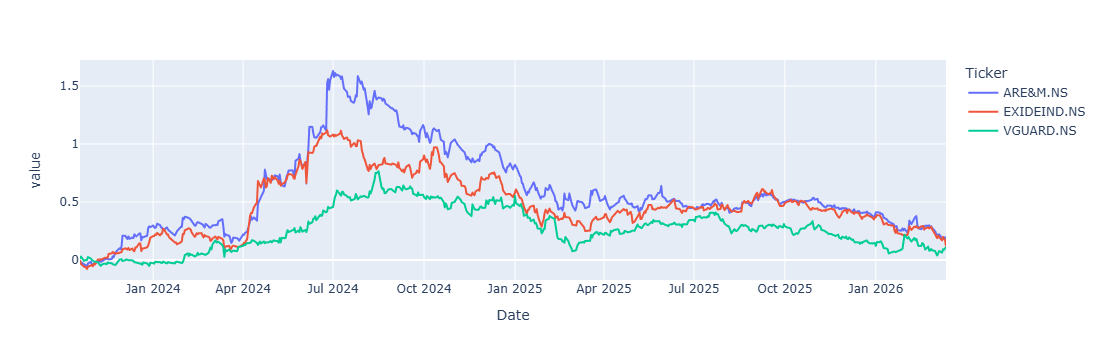

In [15]:
daily_cum_returns.plot()

# Wealth Index

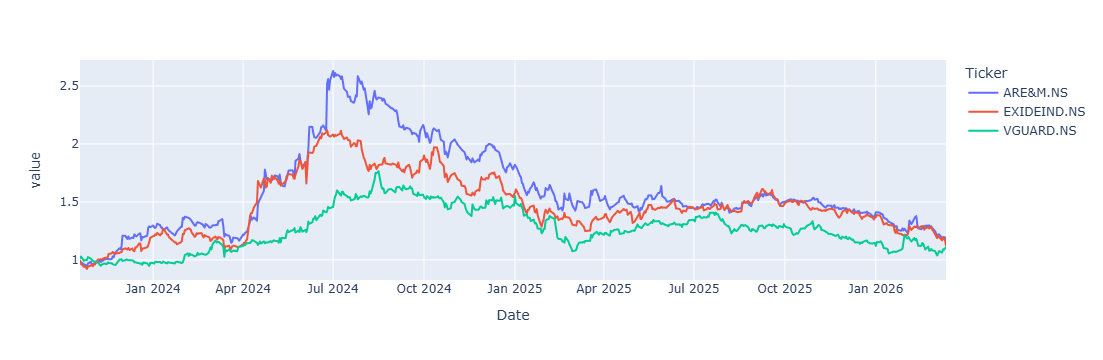

In [18]:
wealth_index = np.exp(log_returns.cumsum())
wealth_index.plot()

 Note: Both graps are coming same (Wealth index and daily cummulative returns) because mathematically they are the same curve—just shifted by a constant.

One starts at 0 (returns) and one starts at 1(wealth)

Risk / Quant / Backtesting → use wealth index

Reporting / Resume / Presentation → use cumulative returns (%)

# Drawdowns

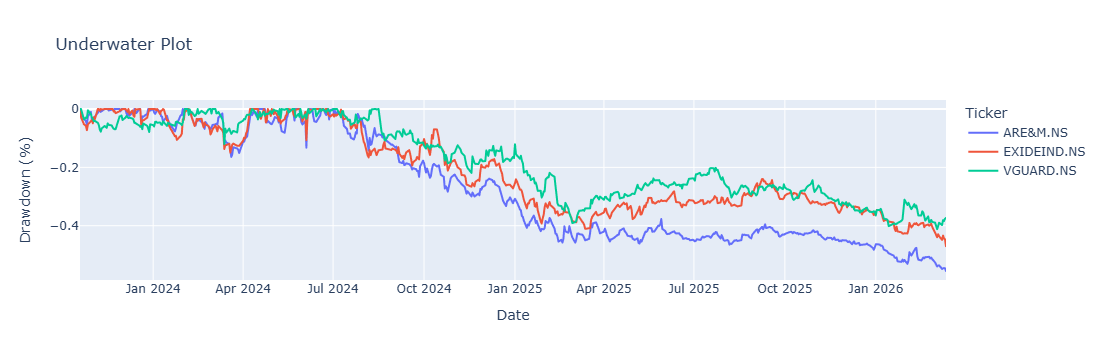

In [46]:
peak = wealth_index.cummax()

drawdown = wealth_index / peak - 1

drawdown.plot(title='Underwater Plot',
              labels={'value':'Drawdown (%)', 'index':'Date'})

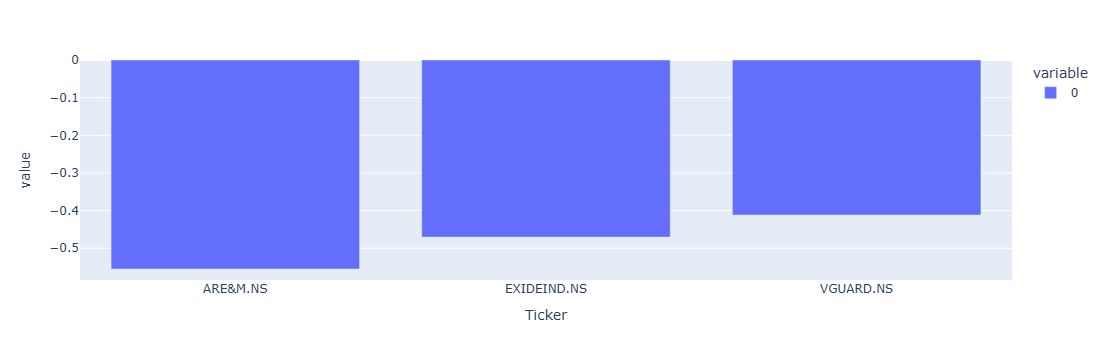

In [50]:
max_dd = drawdown.min()
max_dd.plot(kind='bar')